basmala mohamed aburass
2320222123

Download libraries

In [61]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

Download data file

In [62]:
df =pd.read_csv('/insurance.csv')

Data analysis and exploration

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [64]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [65]:
df.shape

(1338, 7)

In [66]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

Identifying and cleaning up missing values

In [67]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


There are no empty values ​​to process.

In [68]:
df.duplicated().sum()

np.int64(1)

In [69]:
df.drop_duplicates(inplace=True)

In [70]:
df.duplicated().sum()

np.int64(0)

I processed the duplicate values.

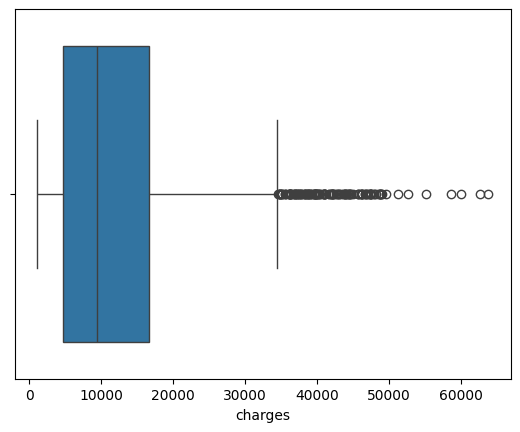

In [71]:
sns.boxplot(x=df["charges"])
plt.show()

In [72]:
Q1 = df["charges"].quantile(0.25)
Q3 = df["charges"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df["charges"] = np.where(
    df["charges"] > upper_bound, upper_bound, df["charges"]
)

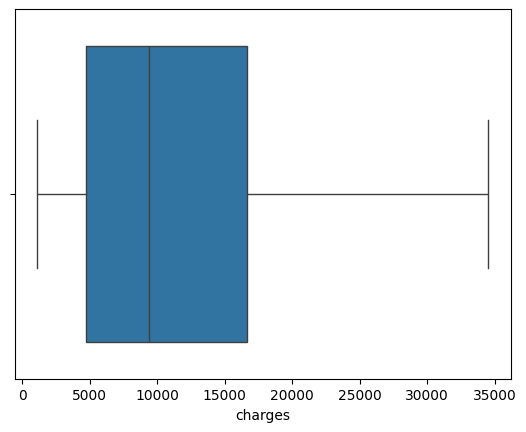

In [73]:
sns.boxplot(x=df["charges"])
plt.show()

I processed the outlier values ​​using IQR

2-EDA

Text(0.5, 0, 'Charges')

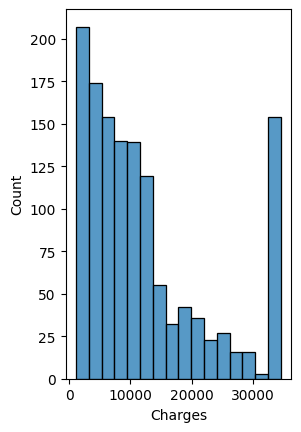

In [74]:
plt.subplot(1,2,1)
sns.histplot(df["charges"])
plt.xlabel("Charges")

I have clarified the target column.

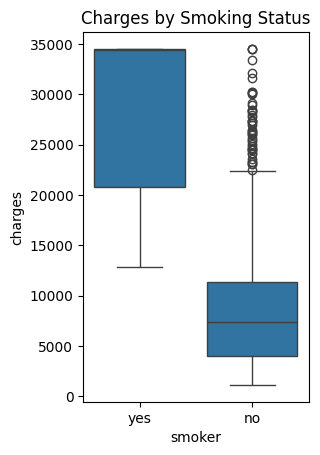

In [75]:
plt.subplot(1, 2, 2)
sns.boxplot(x="smoker", y="charges", data=df)
plt.title("Charges by Smoking Status")
plt.show()

The image shows that smokers require higher expenses than non-smokers.

3-Feature Engineering

In [79]:
X = df.drop(columns=["charges"])
y = df["charges"]

X = pd.get_dummies(X, columns=["sex", "smoker", "region"], drop_first=True)

num_cols = ["age", "bmi", "children"]
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])


In [80]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1337 non-null   float64
 1   bmi               1337 non-null   float64
 2   children          1337 non-null   float64
 3   sex_male          1337 non-null   bool   
 4   smoker_yes        1337 non-null   bool   
 5   region_northwest  1337 non-null   bool   
 6   region_southeast  1337 non-null   bool   
 7   region_southwest  1337 non-null   bool   
dtypes: bool(5), float64(3)
memory usage: 48.3 KB


In [ ]:
X.head()

4-sperate the data to training and test


In [84]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
l_model = LinearRegression()
l_model.fit(X_train, y_train)

train_result = l_model.score(X_train, y_train)
test_result = l_model.score(X_test, y_test)

print(f"\nAccuracy of linear regression on training data : {train_score:.4f}")
print(f"Accuracy of linear regression on test data: {test_score:.4f}")


Accuracy of linear regression on training data : 0.7252
Accuracy of linear regression on test data: 0.8210


5-Regularization and K-Fold

In [91]:
ridge_model = Ridge(alpha=1.0)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(ridge_model, X_train, y_train, cv=kf, scoring="r2")

print(f"Values ​​for each fold: {cv_scores}")
print(f"Average accuracy (Mean R^2): {cv_scores.mean():.4f}")
print(f"Standard deviation of accuracy(Standard Deviation): {cv_scores.std():.4f}")

Values ​​for each fold: [0.7090709  0.72642425 0.79702593 0.68408622 0.6877037 ]
Average accuracy (Mean R^2): 0.7209
Standard deviation of accuracy(Standard Deviation): 0.0410


In [92]:
ridge_model.fit(X_train, y_train)
final_test_score = ridge_model.score(X_test, y_test)
print(
    f"\nFinal accuracy of the Ridge model on test data (R^2): {final_test_score:.4f}"
)


Final accuracy of the Ridge model on test data (R^2): 0.8204
